# Exploratory Data Analysis (EDA)

This notebook explores the cleaned groundwater monitoring dataset to understand:

- Distribution of groundwater levels
- Temporal trends
- Station-wise variability
- Seasonal behavior
- Data characteristics that will guide feature engineering

The dataset used here has already undergone data cleaning and validation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 5)

# Load cleaned dataset
df = pd.read_csv("/content/groundwater_cleaned.csv")

# Convert timestamp
df["Data Acquisition Time"] = pd.to_datetime(
    df["Data Acquisition Time"]
)

target = "Groundwater Level Telemetry 6 Hourly (meter)"

print("Dataset Shape:", df.shape)
print("Stations:", df["Station"].nunique())
print("Date Range:")
print(df["Data Acquisition Time"].min())
print(df["Data Acquisition Time"].max())

df.head()

Dataset Shape: (99445, 7)
Stations: 25
Date Range:
2021-09-27 00:00:00
2025-12-30 18:00:00


,Station,Data Acquisition Time,Latitude,Longitude,Groundwater Level Telemetry 6 Hourly (meter),RL_MSL,time_diff
0,Adakamaranahalli,2021-09-27 00:00:00,13.07,77.45,-22.51,849.0,NaN
1,Adakamaranahalli,2021-09-27 06:00:00,13.07,77.45,-22.87,849.0,0 days 06:00:00
2,Adakamaranahalli,2021-09-27 12:00:00,13.07,77.45,-23.23,849.0,0 days 06:00:00
3,Adakamaranahalli,2021-09-27 18:00:00,13.07,77.45,-22.66,849.0,0 days 06:00:00
4,Adakamaranahalli,2021-09-28 00:00:00,13.07,77.45,-22.46,849.0,0 days 06:00:00


## Step 2: Overall Target Distribution

This section examines the overall distribution of the groundwater level target variable.

The analysis includes:

- Summary statistics
- Histogram
- Kernel Density Estimate (KDE)
- Boxplot

This helps identify the distribution shape, spread, and any remaining extreme observations after data cleaning.

In [2]:
# Summary statistics

print(df[target].describe())

count    99445.000000
mean       -25.228653
std         36.196832
min       -190.106000
25%        -28.843000
50%        -18.321000
75%        -10.298000
max         79.026000
Name: Groundwater Level Telemetry 6 Hourly (meter), dtype: float64


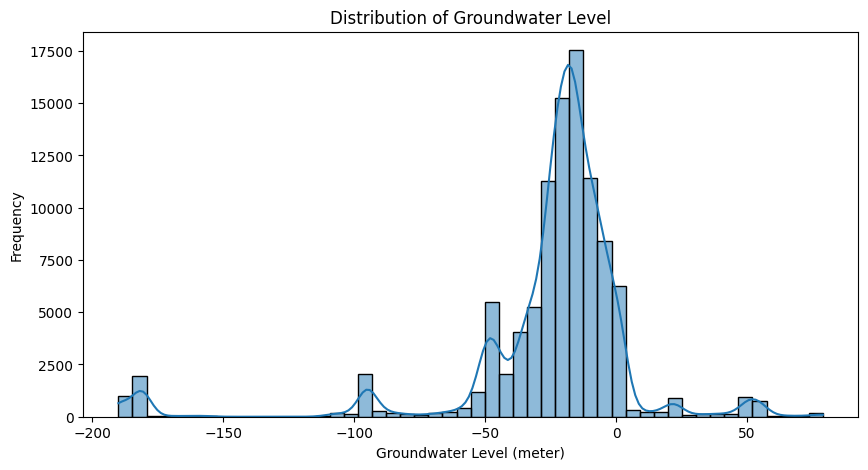

In [3]:
# Histogram + KDE

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x=target,
    bins=50,
    kde=True
)

plt.title("Distribution of Groundwater Level")
plt.xlabel("Groundwater Level (meter)")
plt.ylabel("Frequency")

plt.show()

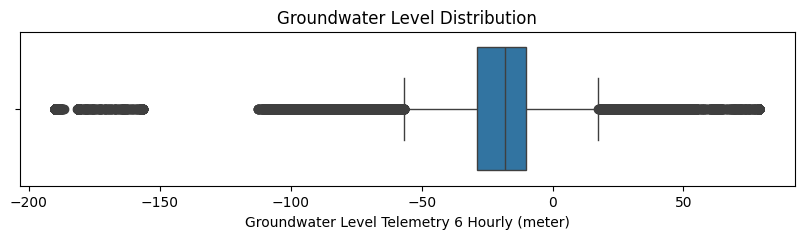

In [4]:
# Boxplot

plt.figure(figsize=(10,2))

sns.boxplot(
    x=df[target]
)

plt.title("Groundwater Level Distribution")

plt.show()

## Step 3: Station-wise Groundwater Level Distribution

Groundwater depth is expected to vary considerably across monitoring stations due to differences in local geology, recharge conditions, and aquifer characteristics.

This section compares the target distribution across stations using descriptive statistics and boxplots.

In [5]:
# Station-wise descriptive statistics

station_stats = (
    df.groupby("Station")[target]
      .agg(
          count="count",
          mean="mean",
          median="median",
          std="std",
          minimum="min",
          maximum="max"
      )
      .round(2)
      .sort_values("median")
)

station_stats

,count,mean,median,std,minimum,maximum
Station,,,,,,
K Narayanapura,3317,-174.76,-181.34,38.55,-190.11,1.00
Avalahalli,3110,-74.55,-94.84,33.46,-95.49,1.00
Doddakannahalli,4345,-44.39,-49.12,9.49,-50.34,1.00
Anekal_1,3007,-48.25,-48.30,5.41,-63.47,1.00
Jakkur_1,3721,-48.96,-42.09,27.80,-112.35,1.00
Byadarahalli,4612,-31.45,-34.28,9.05,-37.96,48.36
Rajanukunte,4107,-27.39,-28.70,8.92,-49.19,1.00
Thotagere,3072,-26.83,-25.74,5.36,-39.76,1.00
Sarjapura_1,4657,-26.67,-24.80,12.28,-66.41,1.00


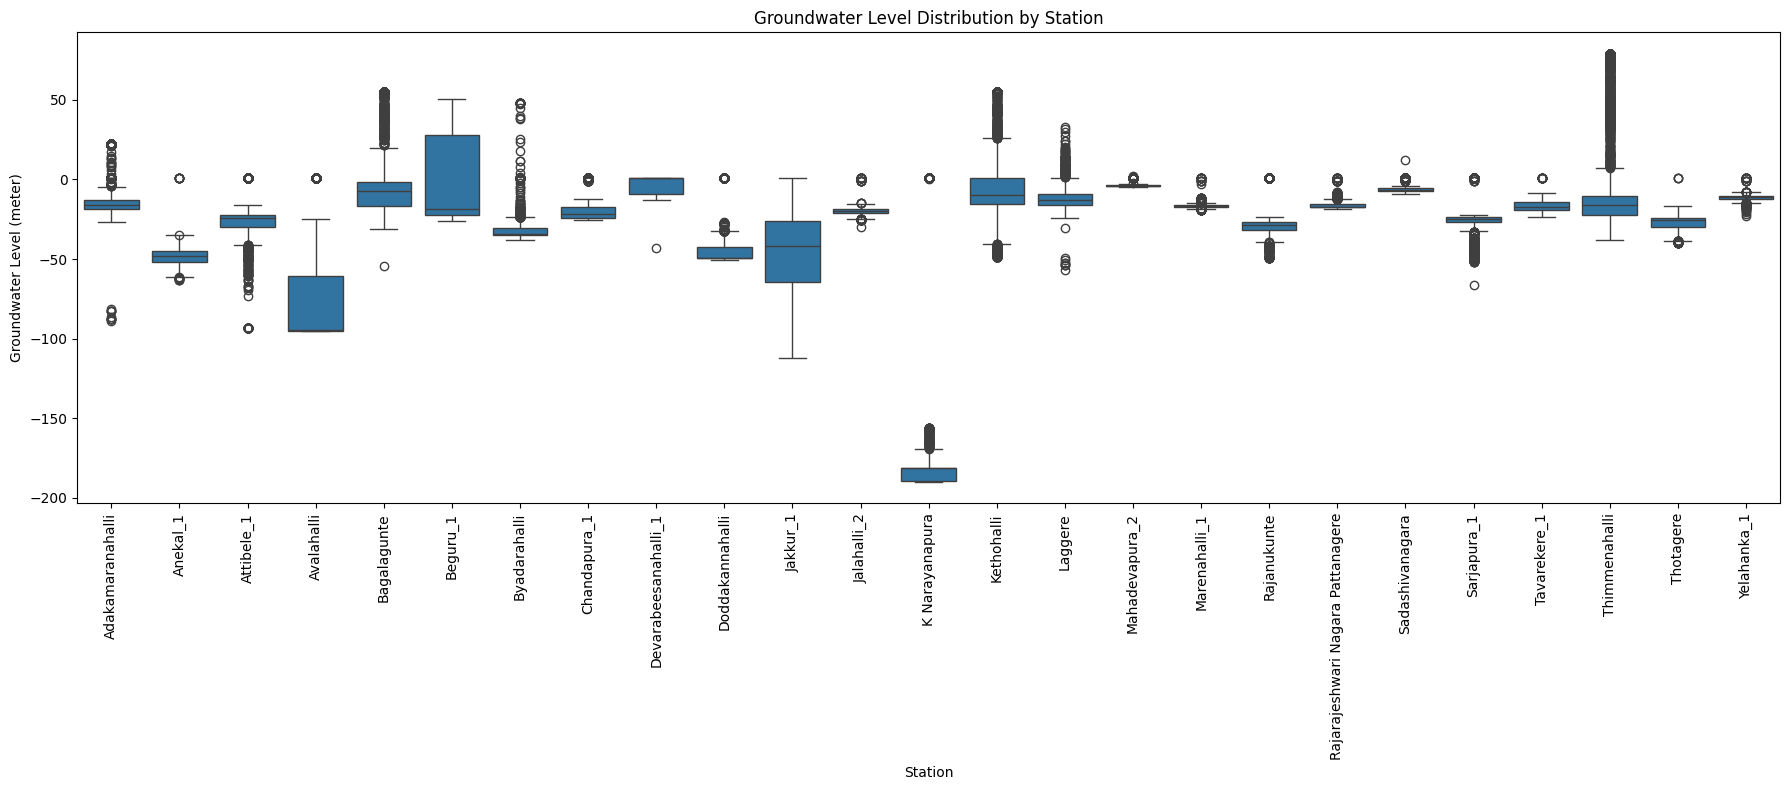

In [6]:
# Station-wise boxplots

plt.figure(figsize=(18,8))

sns.boxplot(
    data=df,
    x="Station",
    y=target
)

plt.xticks(rotation=90)

plt.title("Groundwater Level Distribution by Station")
plt.xlabel("Station")
plt.ylabel("Groundwater Level (meter)")

plt.tight_layout()
plt.show()

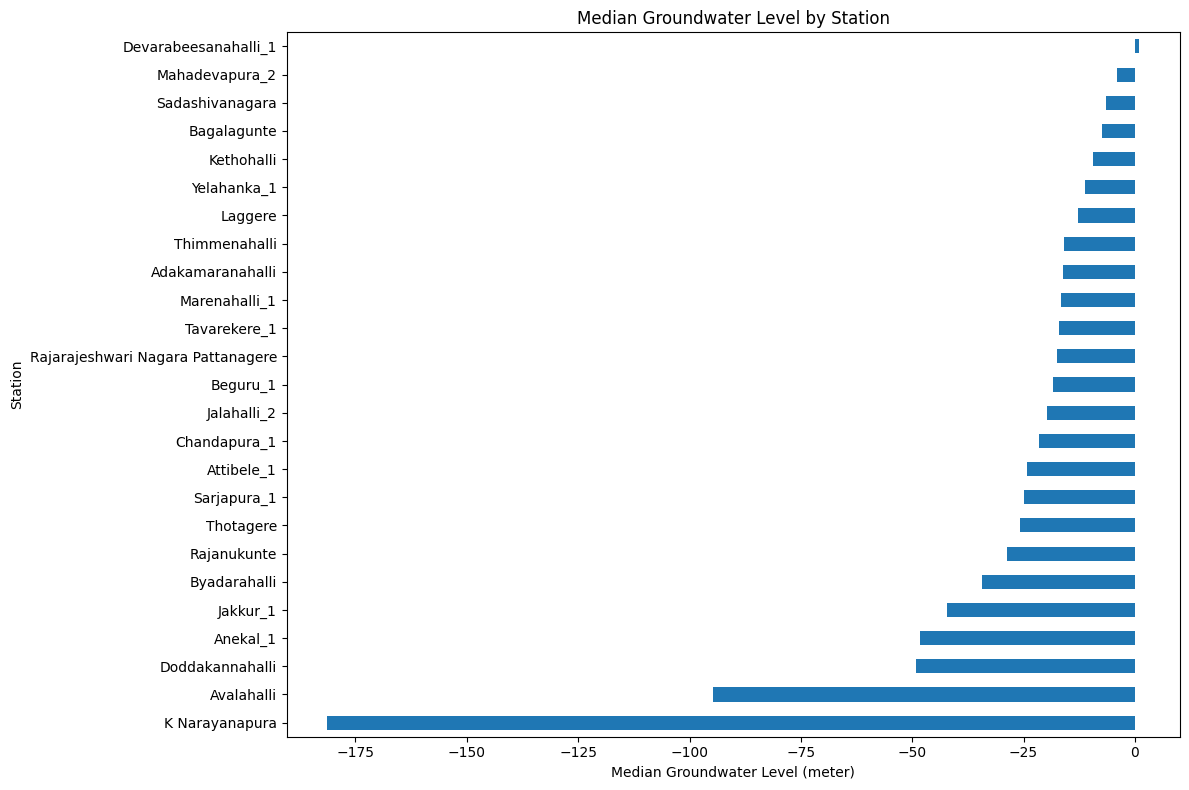

In [7]:
# Station-wise median groundwater level

plt.figure(figsize=(12,8))

station_stats["median"].sort_values().plot(kind="barh")

plt.title("Median Groundwater Level by Station")
plt.xlabel("Median Groundwater Level (meter)")
plt.ylabel("Station")

plt.tight_layout()
plt.show()